# Հայերեն Ձեռագիր Տեքստի Գեներացիա (Mashtots Dataset)

**Նպատակը:**
Ստեղծել գեներատիվ նեյրոնային ցանց, որը տրված հայերեն տեքստը կվերածի իրական ձեռագրի

###  Ճարտարապետությունների Ընտրություն
1. **Conditional VAE** (Baseline 1) - Ստանդարտ  մոդել (MSE Loss):
2. **DDPM / Diffusion** (Baseline 2) - Ժամանակակից աղմուկը մաքրող մոդել:
3. **AC-WGAN-GP**  - Մրցակցային մոդել Gradient Penalty-ով:

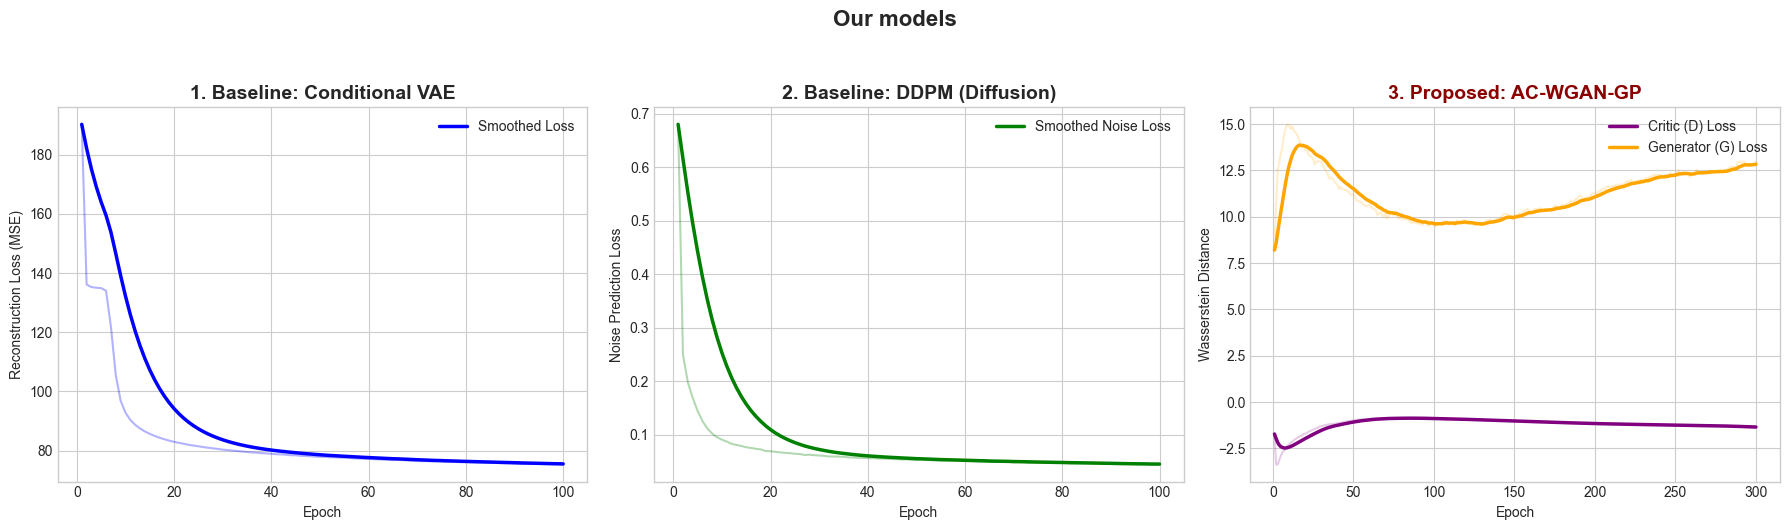

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

def smooth(scalars, weight=0.85):
    if len(scalars) == 0: return []
    last = scalars[0]
    smoothed = []
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

def parse_acgan_log(txt_path):
    epochs, d_losses, g_losses = [], [], []
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as file:
            for line in file.readlines():
                match = re.search(r"\[Epoch\s+(\d+)/\d+\]\s+D_loss:\s+([-\d\.]+)\s+G_loss:\s+([-\d\.]+)", line)
                if match:
                    epochs.append(int(match.group(1)))
                    d_losses.append(float(match.group(2)))
                    g_losses.append(float(match.group(3)))
    return pd.DataFrame({'Epoch': epochs, 'D_Loss': d_losses, 'G_Loss': g_losses})

# Բեռնում ենք տվյալները
df_vae = pd.read_csv(r'/losses/vae_loss.csv') if os.path.exists('../losses/vae_loss.csv') else pd.DataFrame()
df_ddpm = pd.read_csv(r'/losses/ddpm_loss.csv') if os.path.exists('../losses/ddpm_loss.csv') else pd.DataFrame()
df_acgan = parse_acgan_log(r'/losses/acgan_log.txt')

# Գծում ենք
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Our models', fontsize=16, fontweight='bold', y=1.05)

if not df_vae.empty:
    axes[0].plot(df_vae.iloc[:, 0], df_vae.iloc[:, 1], alpha=0.3, color='blue')
    axes[0].plot(df_vae.iloc[:, 0], smooth(df_vae.iloc[:, 1].values), label='Smoothed Loss', color='blue', lw=2.5)
    axes[0].set_title('1. Baseline: Conditional VAE', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Reconstruction Loss (MSE)')
    axes[0].legend()

if not df_ddpm.empty:
    axes[1].plot(df_ddpm.iloc[:, 0], df_ddpm.iloc[:, 1], alpha=0.3, color='green')
    axes[1].plot(df_ddpm.iloc[:, 0], smooth(df_ddpm.iloc[:, 1].values), label='Smoothed Noise Loss', color='green', lw=2.5)
    axes[1].set_title('2. Baseline: DDPM (Diffusion)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Noise Prediction Loss')
    axes[1].legend()

if not df_acgan.empty:
    axes[2].plot(df_acgan['Epoch'], df_acgan['D_Loss'], alpha=0.2, color='purple')
    axes[2].plot(df_acgan['Epoch'], smooth(df_acgan['D_Loss'].values), label='Critic (D) Loss', color='purple', lw=2.5)
    axes[2].plot(df_acgan['Epoch'], df_acgan['G_Loss'], alpha=0.2, color='orange')
    axes[2].plot(df_acgan['Epoch'], smooth(df_acgan['G_Loss'].values), label='Generator (G) Loss', color='orange', lw=2.5)
    axes[2].set_title('3. Proposed: AC-WGAN-GP', fontsize=14, fontweight='bold', color='darkred')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Wasserstein Distance')
    axes[2].legend()

plt.tight_layout()
plt.show()

###  Գրաֆիկների Մաթեմատիկական Վերլուծություն

* **VAE-ն** արագ կայունանում է, քանի որ MSE ֆունկցիան ստիպում է ցանցին գտնել «միջինացված» անվտանգ տարբերակ, բայց արդյունքում ունենում ենք «աղոտ» պատկեր ։
* **DDPM:** Սովորում է դանդաղ, իսկ գեներացիայի փուլը չափազանց ռեսուրսատար է: Սա թույլ չի տալիս այն օգտագործել Real-time վեբ հավելվածներում, որտեղ արագությունն առանցքային է:
* **AC-WGAN-GP-ում** Այստեղ գործ ունենք դասական Նեշի հավասարակշռության հետ: Գեներատորի լոսի աճը (դեղին գիծը) չի նշանակում, թե մոդելը վատ է աշխատում. պարզապես Critic-ն է դառնում ավելի «պահանջկոտ», ինչն էլ ստիպում է գեներատորին էլ ավելի կատարելագործվել:

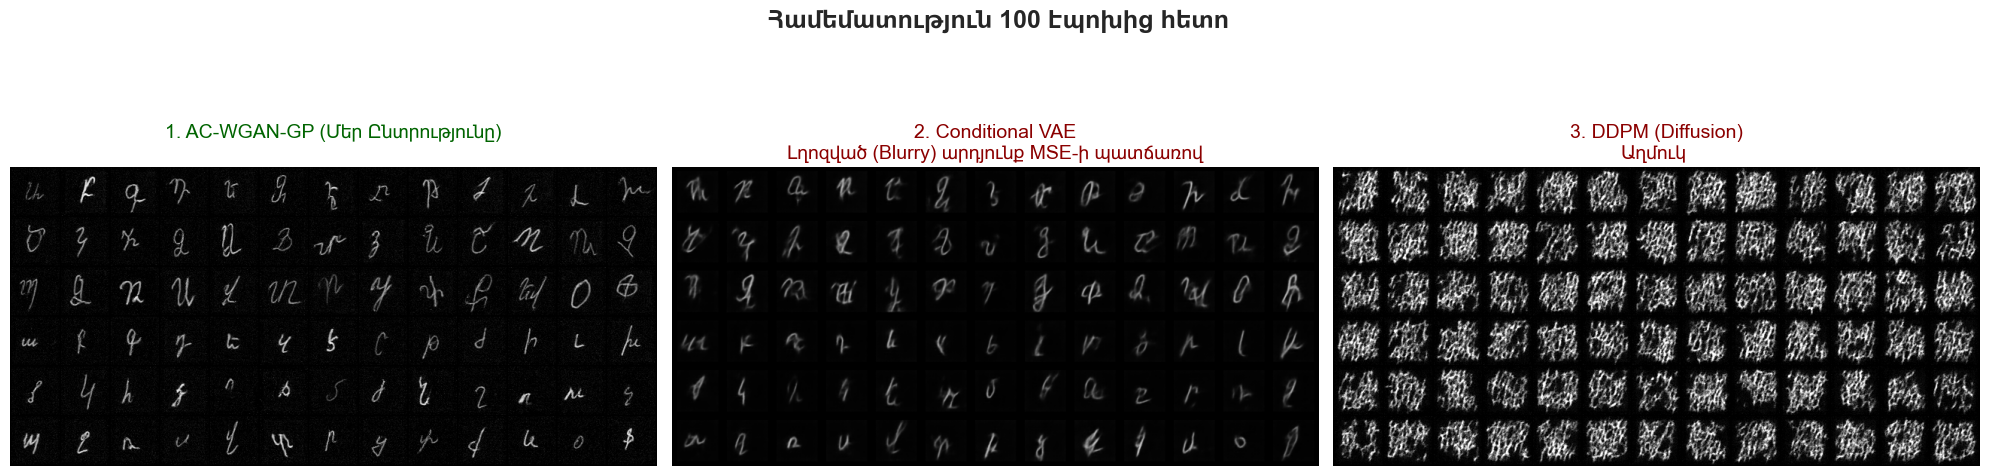

In [2]:
import matplotlib.image as mpimg

img_acgan = mpimg.imread(r'C:\Users\srbuh\Downloads\Telegram Desktop\AC_WGAN-17_03_26\samples_100\acgan_sample.png')
img_vae = mpimg.imread(r'C:\Users\srbuh\Downloads\Telegram Desktop\AC_WGAN-17_03_26\samples_100\vae_sample.png')
img_ddpm = mpimg.imread(r'C:\Users\srbuh\Downloads\Telegram Desktop\AC_WGAN-17_03_26\samples_100\ddpm_sample.png')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(' Համեմատություն 100 էպոխից հետո', fontsize=18, fontweight='bold')

axes[0].imshow(img_acgan, cmap='gray')
axes[0].set_title('1. AC-WGAN-GP (Մեր Ընտրությունը)\n', fontsize=14, color='darkgreen')
axes[0].axis('off')

axes[1].imshow(img_vae, cmap='gray')
axes[1].set_title('2. Conditional VAE\nԼղոզված (Blurry) արդյունք MSE-ի պատճառով', fontsize=14, color='darkred')
axes[1].axis('off')

axes[2].imshow(img_ddpm, cmap='gray')
axes[2].set_title('3. DDPM (Diffusion)\nԱղմուկ ', fontsize=14, color='darkred')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [3]:
import torch
import numpy as np
import cv2
import gradio as gr
from PIL import Image, ImageChops
from src.model import Generator
from src.dataset import CHAR_TO_CLASS, NUM_CLASSES

CHECKPOINT_PATH = r"C:\Users\srbuh\Downloads\Telegram Desktop\AC_WGAN-17_03_26\checkpoints\checkpoint_epoch_0300.pt"
LATENT_DIM = 100
IMG_SIZE = 64
DIGRAPHS = {'ու': 63, 'Ու': 24, 'Եվ': 36, 'և': 75}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

G = Generator(num_classes=NUM_CLASSES, latent_dim=LATENT_DIM, embed_dim=LATENT_DIM).to(device)
try:
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    G.load_state_dict(ckpt['G_state_dict'])
    G.eval()
except Exception as e:
    print(f"ԶԳՈՒՇԱՑՈՒՄ: Մոդելը չբեռնվեց: {e}")

def tokenize(word: str) -> list:
    tokens, i = [], 0
    while i < len(word):
        two = word[i:i + 2]
        if two in DIGRAPHS:
            tokens.append((two, DIGRAPHS[two]))
            i += 2
            continue
        ch = word[i]
        if ch in CHAR_TO_CLASS:
            tokens.append((ch, CHAR_TO_CLASS[ch]))
        i += 1
    return tokens

def change_image_color(img_rgba, color="white"):
    r, g, b, a = img_rgba.split()
    if color == "white":
        r = r.point(lambda _: 255); g = g.point(lambda _: 255); b = b.point(lambda _: 255)
    return Image.merge("RGBA", (r, g, b, a))

def generate_word_image(word: str, fixed_noise: torch.Tensor, pad: int = -18):
    tokens = tokenize(word)
    if not tokens: return None
    elements = []
    with torch.no_grad():
        for _, class_id in tokens:
            label = torch.tensor([class_id], device=device)
            img_tensor = G(fixed_noise, label)
            img_tensor = (img_tensor + 1) / 2.0
            img_arr = img_tensor.squeeze().cpu().numpy() * 255
            elements.append(Image.fromarray(img_arr.astype(np.uint8), mode='L'))

    total_width = max(IMG_SIZE, sum(el.width for el in elements) + pad * (len(elements) - 1))
    word_img = Image.new('L', (total_width, IMG_SIZE), color=0)
    x_offset = 0
    for el in elements:
        temp_canvas = Image.new('L', (total_width, IMG_SIZE), color=0)
        temp_canvas.paste(el, (x_offset, 0))
        word_img = ImageChops.lighter(word_img, temp_canvas)
        x_offset += el.width + pad

    arr = np.array(word_img).astype(np.uint8)
    _, mask = cv2.threshold(cv2.GaussianBlur(arr, (3, 3), 0), 40, 255, cv2.THRESH_BINARY)
    mask = cv2.dilate(mask, np.ones((2, 2), np.uint8), iterations=1)
    _, final_mask = cv2.threshold(cv2.GaussianBlur(mask, (3, 3), 0), 127, 255, cv2.THRESH_BINARY)

    rgba = np.zeros((*final_mask.shape, 4), dtype=np.uint8)
    rgba[..., 3] = final_mask
    return Image.fromarray(rgba, 'RGBA')

def process_pipeline(text, bg_img, color_mode, font_scale):
    if not text.strip(): return None, "Մուտքագրեք տեքստ"

    if bg_img is None:
        bg_img = Image.new("RGB", (1000, 1000), "black" if color_mode == "Սպիտակ" else "white")
    else:
        bg_img = bg_img.convert("RGBA")

    text_color = "white" if color_mode == "Սպիտակ" else "black"
    if color_mode == "Ավտոմատ":
        roi = bg_img.crop((int(bg_img.width*0.2), int(bg_img.height*0.2), int(bg_img.width*0.8), int(bg_img.height*0.8)))
        arr = np.array(roi.convert("RGB"))
        avg_brightness = np.mean(0.299*arr[:,:,0] + 0.587*arr[:,:,1] + 0.114*arr[:,:,2])
        text_color = "white" if avg_brightness < 127 else "black"

    target_height = int(max(30, int(bg_img.width * 0.04)) * font_scale)
    scale = target_height / float(IMG_SIZE)
    space_width, line_spacing = int(40 * scale), int(target_height * 0.8)

    margin_x, margin_y = int(bg_img.width * 0.08), int(bg_img.height * 0.08)
    current_x, current_y = margin_x, margin_y
    max_x = bg_img.width - margin_x

    fixed_noise = torch.randn(1, LATENT_DIM, device=device)
    final_canvas = bg_img.copy()

    for paragraph in text.split('\n'):
        if not paragraph.strip():
            current_y += target_height + line_spacing
            continue
        for word in paragraph.split():
            word_img = generate_word_image(word, fixed_noise)
            if not word_img: continue

            new_w = int(word_img.width * scale)
            word_img = word_img.resize((new_w, target_height), Image.LANCZOS)
            if text_color == "white": word_img = change_image_color(word_img, "white")

            if current_x + new_w > max_x:
                current_x = margin_x
                current_y += target_height + line_spacing

            final_canvas.paste(word_img, (current_x, current_y), word_img)
            current_x += new_w + space_width
        current_x = margin_x
        current_y += target_height + line_spacing

    return final_canvas.convert("RGB"), f"Գեներացված է: Գույնը՝ {text_color}"

# Վեբ ինտերֆեյսը գործարկվում է Jupyter-ի ներսում (inline=True)
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    with gr.Row():
        with gr.Column(scale=1):
            text_input = gr.Textbox(label="Հայերեն Տեքստ", placeholder="Գրեք հայերեն տեքստ...", lines=5)
            bg_input = gr.Image(label="Ֆոն ", type="pil")
            font_scale = gr.Slider(0.5, 3.0, 1.0, label="Տառաչափ")
            color_radio = gr.Radio(["Ավտոմատ", "Սև", "Սպիտակ"], value="Ավտոմատ", label="Գույն")
            submit_btn = gr.Button("Գեներացնել", variant="primary")
        with gr.Column(scale=2):
            output_image = gr.Image(label="Արդյունք", type="pil")
            output_info = gr.Textbox(label="Ինֆորմացիա", interactive=False)

    submit_btn.click(fn=process_pipeline, inputs=[text_input, bg_input, color_radio, font_scale], outputs=[output_image, output_info])

demo.launch(inline=True, share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://fa52f911ea903ffbbd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
